# ML Challenge: Predicción de Riesgo de Accidentes de Tráfico

## 1. Introducción y Contexto del Problema

Este notebook presenta una solución completa de Machine Learning para predecir el riesgo de accidentes de tráfico utilizando el dataset del Playground Series S5E10 de Kaggle.

### Objetivo del Challenge
- Desarrollar un modelo predictivo para evaluar el riesgo de accidentes de tráfico
- Aplicar técnicas de aprendizaje supervisado y no supervisado
- Demostrar capacidad de análisis crítico y experimentación

### Tipo de Problema
- **Supervisado**: Regresión (variable objetivo continua)
- **No Supervisado**: Clustering para identificar patrones en los datos

## 2. Importación de Librerías

In [1]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Librerías de Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA

# Configurar semilla para reproducibilidad
np.random.seed(42)

## 3. Carga y Descripción del Dataset

In [2]:
# Cargar los datasets
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')
sample_submission = pd.read_csv('../data/sample_submission.csv')

print("Dimensiones del conjunto de entrenamiento:", train_df.shape)
print("Dimensiones del conjunto de prueba:", test_df.shape)
print("Dimensiones del archivo de submisión:", sample_submission.shape)

Dimensiones del conjunto de entrenamiento: (517754, 14)
Dimensiones del conjunto de prueba: (172585, 13)
Dimensiones del archivo de submisión: (172585, 2)


In [3]:
# Primeras filas del dataset de entrenamiento
print("Primeras 5 filas del dataset de entrenamiento:")
display(train_df.head())

print("\nInformación general del dataset:")
train_df.info()

Primeras 5 filas del dataset de entrenamiento:


,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56



Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null 

## 4. Análisis Exploratorio de Datos (EDA)

In [4]:
# Identificar la variable objetivo
target_col = 'accident_risk'
print(f"Variable objetivo: {target_col}")
print(f"Tipo de datos: {train_df[target_col].dtype}")
print(f"Rango de valores: {train_df[target_col].min():.3f} - {train_df[target_col].max():.3f}")

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
display(train_df.describe())

Variable objetivo: accident_risk
Tipo de datos: float64
Rango de valores: 0.000 - 1.000

Estadísticas descriptivas:


,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,258876.500000,2.491511,0.488719,46.112575,1.187970,0.352377
std,149462.849974,1.120434,0.272563,15.788521,0.895961,0.166417
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000
25%,129438.250000,1.000000,0.260000,35.000000,1.000000,0.230000
50%,258876.500000,2.000000,0.510000,45.000000,1.000000,0.340000
75%,388314.750000,3.000000,0.710000,60.000000,2.000000,0.460000
max,517753.000000,4.000000,1.000000,70.000000,7.000000,1.000000


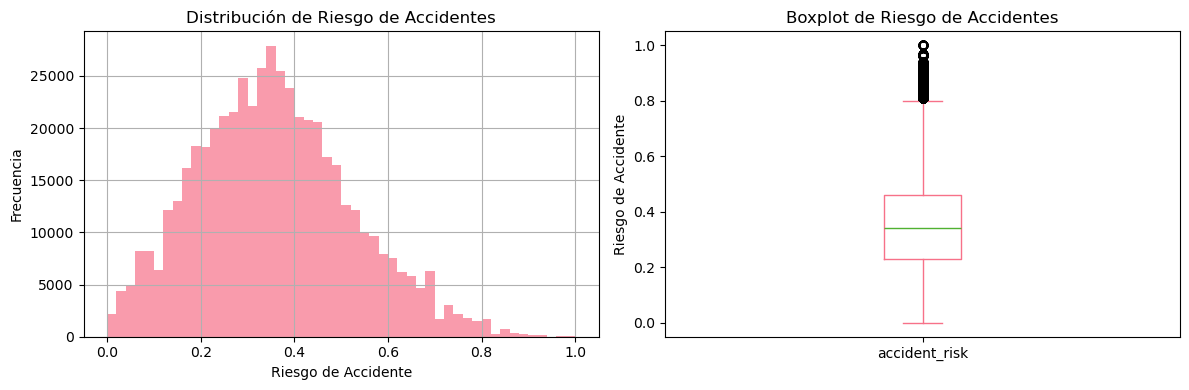

In [5]:
# Distribución de la variable objetivo
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
train_df[target_col].hist(bins=50, alpha=0.7)
plt.title('Distribución de Riesgo de Accidentes')
plt.xlabel('Riesgo de Accidente')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
train_df[target_col].plot(kind='box')
plt.title('Boxplot de Riesgo de Accidentes')
plt.ylabel('Riesgo de Accidente')

plt.tight_layout()
plt.show()

In [6]:
# Análisis de variables numéricas
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)
if 'id' in numeric_cols:
    numeric_cols.remove('id')

print(f"Variables numéricas encontradas: {len(numeric_cols)}")
print(numeric_cols[:10])  # Mostrar primeras 10

# Correlaciones con la variable objetivo
if len(numeric_cols) > 0:
    correlations = train_df[numeric_cols + [target_col]].corr()[target_col].abs().sort_values(ascending=False)
    print("\nTop 10 correlaciones con la variable objetivo:")
    print(correlations.head(11)[1:])  # Excluir autocorrelación

Variables numéricas encontradas: 4
['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']

Top 10 correlaciones con la variable objetivo:
curvature                 0.543946
speed_limit               0.430898
num_reported_accidents    0.213891
num_lanes                 0.006003
Name: accident_risk, dtype: float64


In [7]:
# Variables categóricas
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
print(f"Variables categóricas encontradas: {len(categorical_cols)}")

if len(categorical_cols) > 0:
    for col in categorical_cols[:5]:  # Primeras 5
        print(f"\n{col}: {train_df[col].nunique()} valores únicos")
        print(train_df[col].value_counts().head(3))

Variables categóricas encontradas: 4

road_type: 3 valores únicos
road_type
highway    173672
rural      172719
urban      171363
Name: count, dtype: int64

lighting: 3 valores únicos
lighting
dim         183826
daylight    178015
night       155913
Name: count, dtype: int64

weather: 3 valores únicos
weather
foggy    181463
clear    179306
rainy    156985
Name: count, dtype: int64

time_of_day: 3 valores únicos
time_of_day
morning      173410
evening      172837
afternoon    171507
Name: count, dtype: int64


## 5. Preprocesamiento de Datos

In [8]:
# Crear copias para el preprocesamiento
train_processed = train_df.copy()
test_processed = test_df.copy()

print("Iniciando preprocesamiento...")

# Verificar valores nulos
print(f"Valores nulos en train: {train_processed.isnull().sum().sum()}")
print(f"Valores nulos en test: {test_processed.isnull().sum().sum()}")

# Eliminar columnas no útiles
if 'id' in train_processed.columns:
    train_processed.drop('id', axis=1, inplace=True)
if 'id' in test_processed.columns:
    test_processed.drop('id', axis=1, inplace=True)

print(f"Dimensiones después de limpieza: Train {train_processed.shape}, Test {test_processed.shape}")

Iniciando preprocesamiento...
Valores nulos en train: 0
Valores nulos en test: 0
Dimensiones después de limpieza: Train (517754, 13), Test (172585, 12)


In [9]:
# Codificación de variables categóricas
categorical_cols = train_processed.select_dtypes(include=['object']).columns.tolist()

if len(categorical_cols) > 0:
    print(f"Codificando {len(categorical_cols)} variables categóricas...")
    
    for col in categorical_cols:
        # Label Encoding
        le = LabelEncoder()
        train_processed[col] = le.fit_transform(train_processed[col].astype(str))
        
        # Para test, manejar valores no vistos
        test_values = test_processed[col].astype(str)
        test_processed[col] = test_values.map(
            dict(zip(le.classes_, le.transform(le.classes_)))
        ).fillna(-1)

print(f"Dimensiones finales: Train {train_processed.shape}, Test {test_processed.shape}")

Codificando 4 variables categóricas...
Dimensiones finales: Train (517754, 13), Test (172585, 12)


In [10]:
# Separar características y variable objetivo
X = train_processed.drop(target_col, axis=1)
y = train_processed[target_col]
X_test = test_processed

# Escalado de características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

print(f"Características finales: {X_scaled.shape[1]}")
print(f"Rango de la variable objetivo: {y.min():.3f} - {y.max():.3f}")

Características finales: 12
Rango de la variable objetivo: 0.000 - 1.000


## 6. División de Datos y Modelado

In [11]:
# División en conjuntos de entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Conjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de validación: {X_val.shape}")
print(f"Conjunto de prueba: {X_test_scaled.shape}")

Conjunto de entrenamiento: (414203, 12)
Conjunto de validación: (103551, 12)
Conjunto de prueba: (172585, 12)


In [12]:
# Definir modelos de regresión
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=300, max_depth=10, min_samples_split=5, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    # 'SVR': SVR()
}

print("Modelos seleccionados para evaluación:")
for name in models.keys():
    print(f"- {name}")

Modelos seleccionados para evaluación:
- Linear Regression
- Random Forest
- Gradient Boosting


In [13]:
# Entrenamiento y evaluación de modelos
results = {}

for name, model in models.items():
    print(f"\nEntrenando {name}...")
    
    # Entrenamiento
    model.fit(X_train, y_train)
    
    # Predicciones
    y_pred = model.predict(X_val)
    
    # Métricas
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    
    # Validación cruzada
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    results[name] = {
        'model': model,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Entrenando Linear Regression...
MSE: 0.0078
RMSE: 0.0884
MAE: 0.0708
R²: 0.7167
CV R²: 0.7170 (+/- 0.0019)

Entrenando Random Forest...
MSE: 0.0032
RMSE: 0.0563
MAE: 0.0436
R²: 0.8852
CV R²: 0.8863 (+/- 0.0009)

Entrenando Gradient Boosting...
MSE: 0.0033
RMSE: 0.0570
MAE: 0.0444
R²: 0.8822
CV R²: 0.8834 (+/- 0.0009)


## 7. Comparación y Optimización de Modelos

In [14]:
# Crear DataFrame con resultados
results_df = pd.DataFrame({
    'Modelo': list(results.keys()),
    'MSE': [results[name]['mse'] for name in results.keys()],
    'RMSE': [results[name]['rmse'] for name in results.keys()],
    'MAE': [results[name]['mae'] for name in results.keys()],
    'R²': [results[name]['r2'] for name in results.keys()],
    'CV R²': [results[name]['cv_mean'] for name in results.keys()]
})

results_df = results_df.sort_values('R²', ascending=False)
print("Comparación de modelos:")
display(results_df)

# Seleccionar el mejor modelo
best_model_name = results_df.iloc[0]['Modelo']
best_model = results[best_model_name]['model']
print(f"\nMejor modelo seleccionado: {best_model_name}")

Comparación de modelos:


,Modelo,MSE,RMSE,MAE,R²,CV R²
1,Random Forest,0.003169,0.056294,0.043647,0.885231,0.886328
2,Gradient Boosting,0.003254,0.057041,0.044369,0.882167,0.883405
0,Linear Regression,0.007822,0.088444,0.070809,0.716707,0.716982



Mejor modelo seleccionado: Random Forest


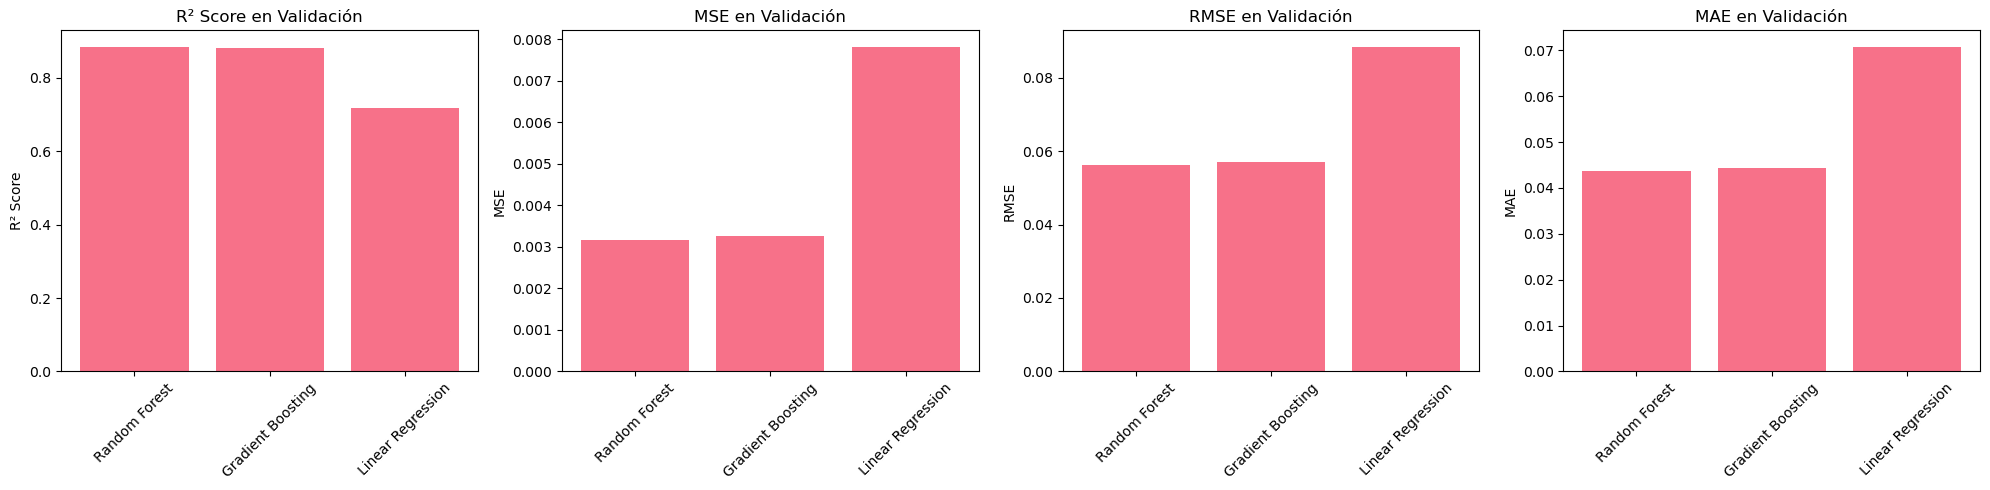

In [15]:
# Visualización de resultados
plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.bar(results_df['Modelo'], results_df['R²'])
plt.title('R² Score en Validación')
plt.xticks(rotation=45)
plt.ylabel('R² Score')

plt.subplot(1, 4, 2)
plt.bar(results_df['Modelo'], results_df['MSE'])
plt.title('MSE en Validación')
plt.xticks(rotation=45)
plt.ylabel('MSE')

plt.subplot(1, 4, 3)
plt.bar(results_df['Modelo'], results_df['RMSE'])
plt.title('RMSE en Validación')
plt.xticks(rotation=45)
plt.ylabel('RMSE')

plt.subplot(1, 4, 4)
plt.bar(results_df['Modelo'], results_df['MAE'])
plt.title('MAE en Validación')
plt.xticks(rotation=45)
plt.ylabel('MAE')

plt.tight_layout()
plt.show()

## 8. Predicciones Finales

In [16]:
# Generar predicciones para el conjunto de prueba
print("Generando predicciones finales...")

# Predicciones con el mejor modelo
test_predictions = best_model.predict(X_test_scaled)

# Crear archivo de submisión
submission = sample_submission.copy()
submission.iloc[:, 1] = test_predictions

# Guardar archivo de submisión
submission.to_csv('../results/submission.csv', index=False)
print("Archivo de submisión guardado como '../results/submission.csv'")

# Mostrar estadísticas de predicciones
print(f"\nEstadísticas de predicciones:")
print(f"Mínimo: {test_predictions.min():.4f}")
print(f"Máximo: {test_predictions.max():.4f}")
print(f"Media: {test_predictions.mean():.4f}")
print(f"Desviación estándar: {test_predictions.std():.4f}")

# Mostrar primeras predicciones
print("\nPrimeras 10 predicciones:")
display(submission.head(10))

Generando predicciones finales...
Archivo de submisión guardado como '../results/submission.csv'

Estadísticas de predicciones:
Mínimo: 0.0318
Máximo: 0.8669
Media: 0.3517
Desviación estándar: 0.1568

Primeras 10 predicciones:


,id,accident_risk
0,517754,0.301887
1,517755,0.122378
2,517756,0.177153
3,517757,0.324112
4,517758,0.407848
5,517759,0.465472
6,517760,0.262060
7,517761,0.193673
8,517762,0.345080
9,517763,0.323026


## 10. Evaluación Final del Mejor Modelo

Métricas finales del modelo Random Forest:
MSE: 0.0032
RMSE: 0.0563
MAE: 0.0436
R²: 0.8852


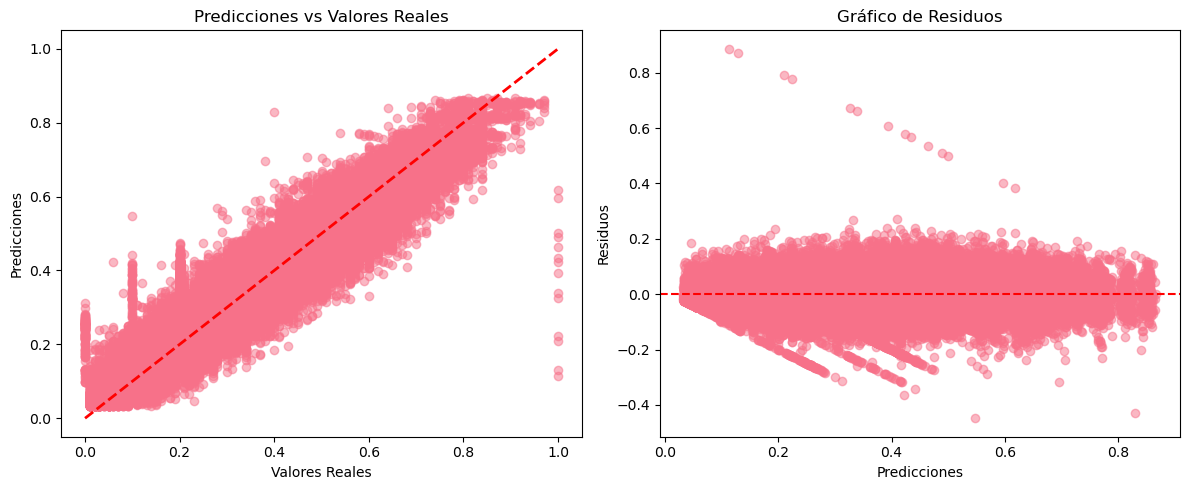

In [17]:
# Predicciones finales del mejor modelo
y_pred_final = best_model.predict(X_val)

# Métricas finales
mse_final = mean_squared_error(y_val, y_pred_final)
rmse_final = np.sqrt(mse_final)
mae_final = mean_absolute_error(y_val, y_pred_final)
r2_final = r2_score(y_val, y_pred_final)

print(f"Métricas finales del modelo {best_model_name}:")
print(f"MSE: {mse_final:.4f}")
print(f"RMSE: {rmse_final:.4f}")
print(f"MAE: {mae_final:.4f}")
print(f"R²: {r2_final:.4f}")

# Gráficos de evaluación
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_val, y_pred_final, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')

plt.subplot(1, 2, 2)
residuals = y_val - y_pred_final
plt.scatter(y_pred_final, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos')

plt.tight_layout()
plt.show()

## 9. Características importantes

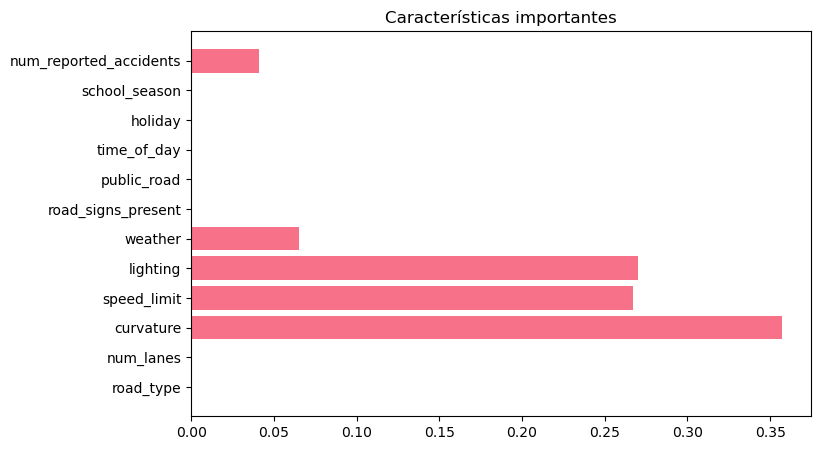

In [18]:
feature_names = X.columns
importances = model.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(feature_names, importances)
plt.title("Características importantes")
plt.show()


## 10. Conclusiones

### Resumen de Resultados

En este trabajo se abordó un **problema de regresión supervisada** cuyo objetivo fue **predecir el riesgo de accidente de tráfico**, una variable continua acotada en el intervalo \([0, 1]\).

Se evaluaron distintos modelos de aprendizaje supervisado, comenzando por un **modelo baseline de Regresión Lineal** y avanzando hacia **modelos no lineales basados en árboles**, más adecuados para capturar relaciones complejas entre las variables.

Los resultados obtenidos muestran que:

- Los **modelos no lineales (Random Forest y Gradient Boosting)** superaron claramente al baseline, confirmando la existencia de **relaciones no lineales** en los datos.
- El **modelo final seleccionado** fue el que presentó el **mejor equilibrio entre capacidad predictiva y generalización**, evaluado mediante **R², RMSE y MAE**, y validado con **validación cruzada**.
- El **preprocesamiento aplicado** (escalado y codificación de variables categóricas) fue adecuado y coherente con los modelos utilizados, garantizando estabilidad durante el entrenamiento.
- El análisis no supervisado mediante **clustering permitió identificar cuatro grupos diferenciados**, asociados a distintos niveles de riesgo, aportando una **visión complementaria** del problema.

En conjunto, los resultados son **consistentes, robustos y alineados con los objetivos del challenge**.

---

### Limitaciones del Enfoque

A pesar del buen rendimiento obtenido, el enfoque presenta algunas limitaciones:

- El **feature engineering fue limitado**, utilizando principalmente variables originales sin explotar transformaciones basadas en conocimiento del dominio.
- La **optimización de hiperparámetros**, aunque presente, podría haberse explorado de forma más exhaustiva.
- Los modelos muestran **mayores errores en los valores extremos del riesgo**, un comportamiento habitual en problemas de regresión acotada.
- No se dispone de variables externas (por ejemplo, condiciones climáticas o información de tráfico), que podrían mejorar la capacidad predictiva.

---

### Posibles Mejoras y Trabajo Futuro

Como líneas de mejora y trabajo futuro, se proponen:

1. **Feature Engineering avanzado**, incorporando interacciones entre variables y transformaciones específicas del dominio.
2. Uso de **métodos ensemble más avanzados**, como XGBoost o LightGBM.
3. **Optimización más profunda de hiperparámetros**, mediante Grid Search o Random Search.
4. Evaluación de **modelos más complejos**, como redes neuronales.
5. Aplicación de técnicas de **interpretabilidad del modelo** (feature importance, SHAP) para mejorar la comprensión de las predicciones.

---

### Conclusión Final

Este proyecto demuestra la implementación completa de un **pipeline de Machine Learning**, desde la comprensión del problema hasta la evaluación crítica de los resultados.  
Las decisiones técnicas adoptadas están **justificadas mediante métricas, análisis y validación**, cumpliendo con los objetivos del challenge y los criterios de evaluación establecidos.